# Activation functions

A composition of affine transformations is still affine. For two layers,

```text
W₂(W₁x + b₁) + b₂ = (W₂W₁)x + (W₂b₁ + b₂)
```

Adding a nonlinear activation between the layers prevents this collapse and gives depth a different function class to work with.


## Sigmoid, tanh, and ReLU

Sigmoid maps inputs to `(0, 1)` and is commonly used to express a binary probability at an output. Tanh maps inputs to `(-1, 1)` and is centered around zero. ReLU is `max(0, x)` and has a constant positive-side derivative.

The first plot shows their values. The second shows the local derivatives at the same input values.


## Saturation and gradient flow

Sigmoid and tanh become nearly flat when the magnitude of the input is large. Their derivatives then become small, so an earlier layer receives a weak gradient. ReLU avoids this on its positive side, but a unit whose inputs remain negative has a zero derivative throughout the observed region.


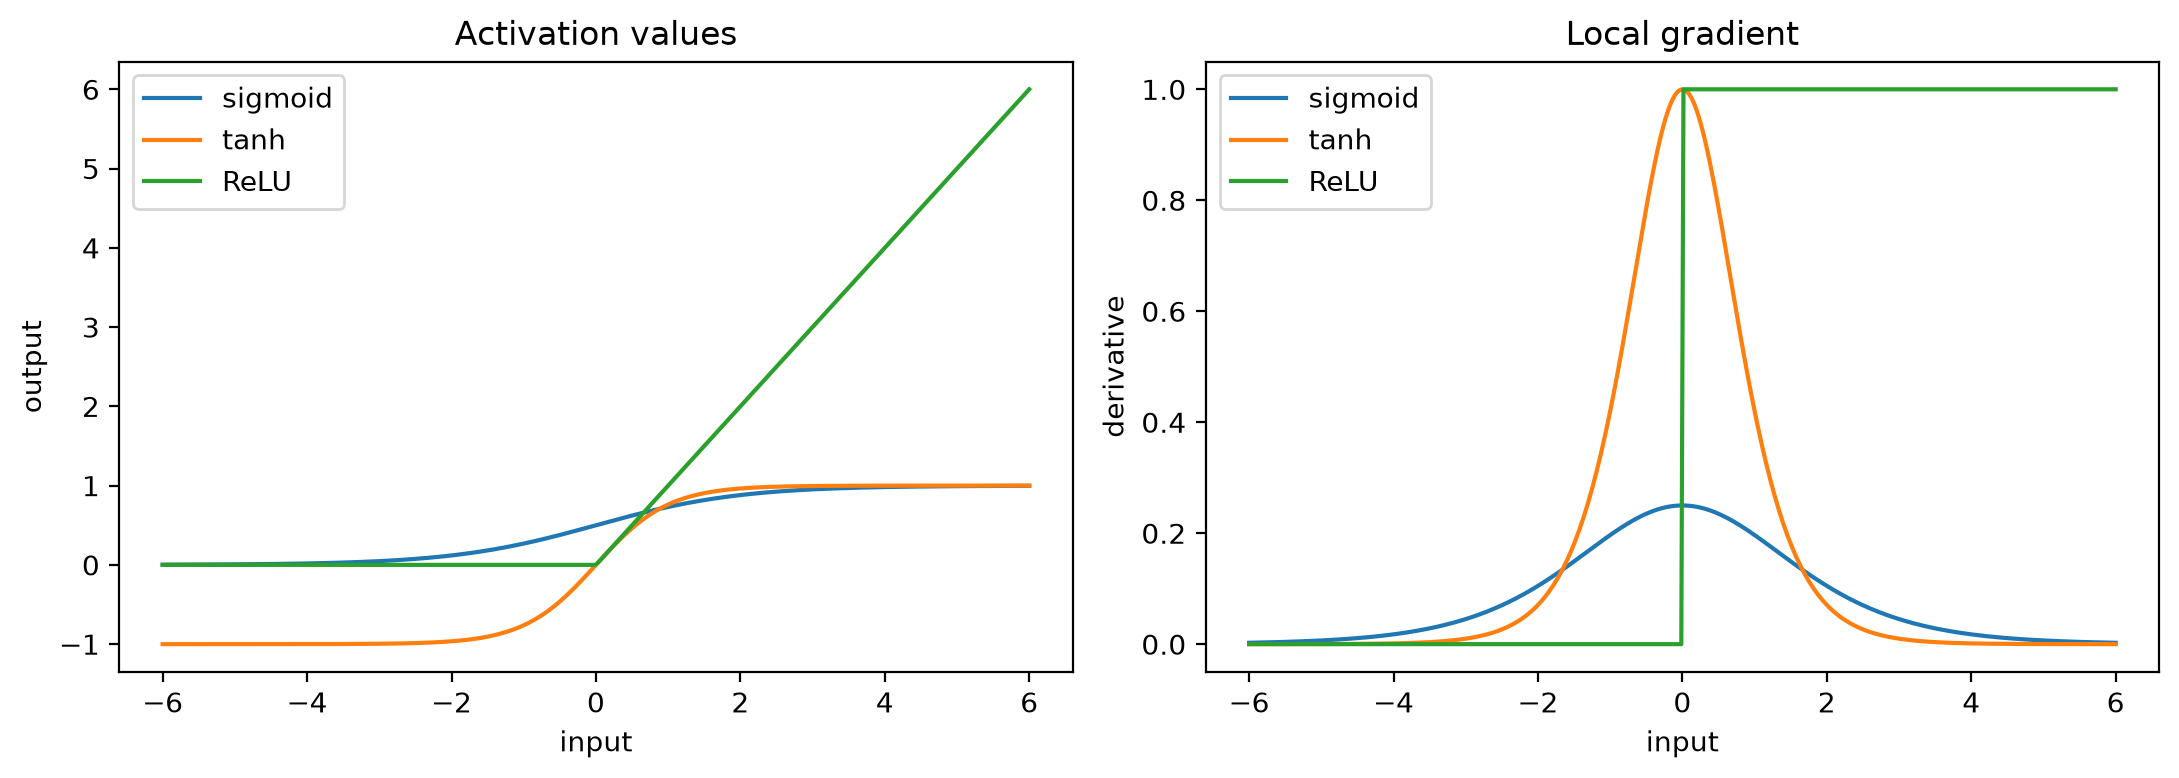

In [1]:
import torch
import matplotlib.pyplot as plt

torch.set_printoptions(precision=4, sci_mode=False)
x = torch.linspace(-6, 6, 400, requires_grad=True)
functions = {
    'sigmoid': torch.sigmoid(x),
    'tanh': torch.tanh(x),
    'ReLU': torch.relu(x),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, values in functions.items():
    axes[0].plot(x.detach(), values.detach(), label=name)
axes[0].set(xlabel='input', ylabel='output', title='Activation values')
axes[0].legend()

for name, values in functions.items():
    grad = torch.autograd.grad(values.sum(), x, retain_graph=True)[0]
    axes[1].plot(x.detach(), grad.detach(), label=name)
axes[1].set(xlabel='input', ylabel='derivative', title='Local gradient')
axes[1].legend()
fig.tight_layout()
plt.show()

## Outputs expected by common losses

`BCEWithLogitsLoss` expects a raw binary logit and applies the sigmoid as part of a numerically stable calculation. `CrossEntropyLoss` expects a vector of class logits and applies the corresponding normalization internally. Applying sigmoid or softmax before these loss functions changes the calculation and can make optimization less stable.


In [2]:
sample_points = torch.tensor([-6.0, 0.0, 6.0])
for name, fn in [('sigmoid', torch.sigmoid), ('tanh', torch.tanh), ('ReLU', torch.relu)]:
    points = sample_points.clone().requires_grad_()
    values = fn(points)
    values.sum().backward()
    print(name)
    print('  values:     ', values.detach().tolist())
    print('  derivatives:', points.grad.tolist())

sigmoid
  values:      [0.0024726230185478926, 0.5, 0.9975274205207825]
  derivatives: [0.0024665091186761856, 0.25, 0.002466465812176466]
tanh
  values:      [-0.9999877214431763, 0.0, 0.9999877214431763]
  derivatives: [2.4556962671340443e-05, 1.0, 2.4556962671340443e-05]
ReLU
  values:      [0.0, 0.0, 6.0]
  derivatives: [0.0, 0.0, 1.0]


## Hidden units

An activation turns an affine response into a nonlinear feature. The next linear layer combines these features. The number of hidden units therefore controls how many learned nonlinear features are available to the model.


## Connection to the MLP

The next notebook keeps one hidden layer and varies its width on a known function. This gives a concrete example of the representational role introduced here.
